# DATA 266 Lab 1 — Task 2: Yelp Polarity Sentiment Classification

**Student:** Yuyao Ding

This notebook contains all the code for preprocessing, training and comparing
three models: mean-pooled embeddings, TextCNN and BiLSTM. Embeddings are trained
from scratch. The model definitions retain the original design.

Run the cells in order. Start with the small smoke run; set
RUN_FORMAL_TRAINING to True for the full experiment. Configuration files remain
in configs, while data, checkpoints, logs and results are saved outside the
notebook. No project Python modules are needed.


## 1. Setup

Use the environment described in README.md. Local Windows, Mac and Linux runs
leave USE_COLAB_DRIVE false. On Colab, enable it and point PROJECT_ROOT to the
complete project on Drive. RESUME_CHECKPOINTS is optional and uses paths
relative to the project root.


In [1]:
USE_COLAB_DRIVE = False
RUN_FORMAL_TRAINING = True
PROJECT_ROOT = None
RESUME_CHECKPOINTS = {}


In [2]:
import hashlib
import importlib.metadata
import json
import os
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import uuid
import zipfile
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from scipy.stats import binomtest
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.metrics import (
    accuracy_score, auc, average_precision_score, brier_score_loss,
    confusion_matrix, f1_score, matthews_corrcoef, precision_recall_curve,
    precision_recall_fscore_support, roc_auc_score
)
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


C:\Users\endle\Downloads\DATA266_Pair41_Lab1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
if USE_COLAB_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    if PROJECT_ROOT is None:
        PROJECT_ROOT = "/content/drive/MyDrive/DATA266_Pair41_Lab1"

if PROJECT_ROOT is None:
    PROJECT_ROOT = next(
        (path for path in (Path.cwd(), *Path.cwd().parents)
         if (path / "task2_sentiment/Yuyao_Ding/src").is_dir()), None
    )
    if PROJECT_ROOT is None:
        raise FileNotFoundError("Open Jupyter inside the project or set PROJECT_ROOT.")

PROJECT_ROOT = Path(PROJECT_ROOT).expanduser().resolve()
MEMBER_DIR = PROJECT_ROOT / "task2_sentiment/Yuyao_Ding"
configs = {
    name: json.loads((MEMBER_DIR / "configs" / (name + ".json")).read_text(encoding="utf-8"))
    for name in ("preprocessing", "models", "training", "evaluation")
}
PREPROCESSING, MODELS = configs["preprocessing"], configs["models"]
TRAINING, EVALUATION = configs["training"], configs["evaluation"]


### Settings and run records

These small helpers check settings, select the device and write files.
Each run gets a new directory, so earlier results and raw logs are preserved.


In [4]:
def validate_configs(configs):
    pre, models, train, evaluation = (configs[name] for name in
                                     ("preprocessing", "models", "training", "evaluation"))
    if train["num_workers"] != 0:
        raise ValueError("Use num_workers=0 for portable notebook execution.")
    for settings, keys in (
        (pre, ("max_length", "min_frequency", "expected_train_rows", "expected_test_rows")),
        (train, ("batch_size", "epochs", "patience", "smoke_train_rows", "smoke_test_rows",
                 "smoke_batch_size", "smoke_max_batches")),
        (evaluation, ("ece_bins", "bootstrap_resamples", "smoke_bootstrap_resamples", "errors_per_category")),
    ):
        if any(not isinstance(settings[key], int) or settings[key] < 1 for key in keys):
            raise ValueError("Counts, sequence lengths and batch sizes must be positive integers.")
    if pre["max_vocab_size"] < 2 or not 0 < pre["validation_fraction"] < 1:
        raise ValueError("Invalid vocabulary size or validation fraction.")
    kernels = models["textcnn"]["kernel_sizes"]
    if not kernels or any(not isinstance(k, int) or k < 1 for k in kernels) or pre["max_length"] < max(kernels):
        raise ValueError("TextCNN kernels must fit within max_length.")
    if any(not 0 <= models[name]["dropout"] < 1 for name in ("baseline", "textcnn", "bilstm")):
        raise ValueError("Dropout must be between zero (inclusive) and one.")
    if min(models["embedding_dim"], models["textcnn"]["num_filters"],
           models["bilstm"]["hidden_dim"], models["bilstm"]["num_layers"]) < 1:
        raise ValueError("Model dimensions must be positive.")
    if train["learning_rate"] <= 0 or train["bilstm_gradient_clip"] <= 0:
        raise ValueError("Learning rate and gradient clip must be positive.")
    if not 0 < evaluation["threshold"] < 1:
        raise ValueError("The decision threshold must be between zero and one.")
    bounds = evaluation["length_slice_quantiles"]
    if len(bounds) != 2 or not 0 < bounds[0] < bounds[1] < 1:
        raise ValueError("Use two increasing length quantiles between zero and one.")
    for key in ("train_file", "test_file", "archive"):
        if Path(pre[key]).name != pre[key]:
            raise ValueError("Dataset filenames must be simple basenames.")


def select_device(requested="auto"):
    if requested == "auto":
        requested = "cuda" if torch.cuda.is_available() else (
            "mps" if torch.backends.mps.is_available() else "cpu"
        )
    if requested not in ("cuda", "mps", "cpu"):
        raise ValueError("Choose auto, cuda, mps, or cpu.")
    if requested == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA is unavailable; use auto or cpu.")
    if requested == "mps" and not torch.backends.mps.is_available():
        raise RuntimeError("MPS is unavailable; use auto or cpu.")
    return torch.device(requested)


def synchronize(device):
    if device.type == "cuda":
        torch.cuda.synchronize(device)
    elif device.type == "mps":
        torch.mps.synchronize()


def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


In [5]:
def file_hash(path):
    with Path(path).open("rb") as file:
        return hashlib.file_digest(file, "sha256").hexdigest()


def save_json(path, data):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_bytes((json.dumps(data, indent=2, ensure_ascii=False, allow_nan=False) + "\n").encode("utf-8"))
    temporary.replace(path)


def save_checkpoint(path, state):
    path = Path(path)
    temporary = path.with_suffix(".tmp")
    torch.save(state, temporary)
    temporary.replace(path)


def copy_checkpoint(source, target):
    target = Path(target)
    temporary = target.with_suffix(".tmp")
    shutil.copy2(source, temporary)
    temporary.replace(target)


In [6]:
def new_session(root, mode, configs):
    root = Path(root)
    member = root / "task2_sentiment/Yuyao_Ding"
    run_id = "task2_" + mode + "_" + datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
    session = {
        "root": root, "member": member, "id": run_id, "mode": mode,
        "processed": member / "data_processed" / run_id,
        "outputs": member / "outputs" / run_id,
        "checkpoints": member / "checkpoints" / run_id,
        "manifests": root / "reproducibility/manifests/Yuyao_Ding" / run_id,
        "logs": root / "reproducibility/raw_logs/Yuyao_Ding"
    }
    for name in ("processed", "outputs", "checkpoints", "manifests", "logs"):
        session[name].mkdir(parents=True, exist_ok=True)
    notebook_path = member / "src/task2_sentiment.ipynb"
    notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
    # Launch controls can change when resuming; the training code must match.
    source = "\n\n".join(
        "".join(cell["source"]) for cell in notebook["cells"]
        if cell["cell_type"] == "code" and "parameters" not in cell["metadata"].get("tags", [])
    )
    session["source_hashes"] = {"notebook_code": hashlib.sha256(source.encode("utf-8")).hexdigest()}
    shutil.copy2(notebook_path, session["manifests"] / "source_notebook.ipynb")
    save_json(session["manifests"] / "configs.json", configs)
    save_json(session["manifests"] / "environment.json", {
        "python": sys.version, "platform": platform.platform(),
        "packages": dict(sorted(
            (package.metadata["Name"], package.version)
            for package in importlib.metadata.distributions() if package.metadata["Name"]
        )),
        "torch_cuda_build": torch.version.cuda, "cudnn_version": torch.backends.cudnn.version()
    })
    return session


In [7]:
def hardware_info(device):
    cpu = platform.processor() or platform.machine()
    if sys.platform == "win32":
        import winreg
        with winreg.OpenKey(winreg.HKEY_LOCAL_MACHINE, r"HARDWARE\DESCRIPTION\System\CentralProcessor\0") as key:
            cpu = winreg.QueryValueEx(key, "ProcessorNameString")[0].strip()
    elif sys.platform == "darwin":
        result = subprocess.run(["sysctl", "-n", "machdep.cpu.brand_string"], capture_output=True, text=True)
        if result.returncode == 0:
            cpu = result.stdout.strip()
    elif Path("/proc/cpuinfo").is_file():
        for line in Path("/proc/cpuinfo").read_text().splitlines():
            if line.startswith("model name"):
                cpu = line.split(":", 1)[1].strip()
                break
    packages = {name: importlib.metadata.version(name) for name in
                ("torch", "numpy", "pandas", "scikit-learn", "scipy", "pyarrow", "matplotlib")}
    return {"device": str(device), "cpu": cpu, "cpu_count": os.cpu_count(),
            "gpu": torch.cuda.get_device_name(device) if device.type == "cuda" else (
                cpu + " (Apple MPS)" if device.type == "mps" else None),
            "python": platform.python_version(), "platform": platform.platform(), "packages": packages,
            "torch_cuda_build": torch.version.cuda, "cudnn_version": torch.backends.cudnn.version(),
            "cudnn_deterministic": torch.backends.cudnn.deterministic,
            "cudnn_benchmark": torch.backends.cudnn.benchmark,
            "float32_matmul_precision": torch.get_float32_matmul_precision()}


def memory_usage(device):
    if sys.platform == "win32":
        import psutil
        peak_rss = psutil.Process().memory_info().peak_wset
    else:
        import resource
        peak_rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        if sys.platform != "darwin":
            peak_rss *= 1024
    result = {"process_lifetime_peak_rss_bytes": int(peak_rss)}
    if device.type == "cuda":
        result["cuda_peak_allocated_bytes"] = torch.cuda.max_memory_allocated(device)
    elif device.type == "mps":
        result["mps_sampled_allocated_bytes"] = torch.mps.current_allocated_memory()
    return result


In [8]:
validate_configs(configs)
SEED = TRAINING["seed"]
seed_everything(SEED)
device = select_device(TRAINING["device"])
MODE = "formal" if RUN_FORMAL_TRAINING else "smoke"
THRESHOLD = EVALUATION["threshold"]
N_BOOTSTRAP = EVALUATION["bootstrap_resamples" if RUN_FORMAL_TRAINING else "smoke_bootstrap_resamples"]
MAX_LEN = PREPROCESSING["max_length"]
EMBEDDING_DIM = MODELS["embedding_dim"]
session = new_session(PROJECT_ROOT, MODE, configs)
DATA_DIR = PROJECT_ROOT / "task2_sentiment/data"
ARTIFACT_DIR = PROCESSED_DIR = session["processed"]
print("Mode:", MODE, "| Session:", session["id"])
display(hardware_info(device))


Mode: smoke | Session: task2_smoke_20260927T015718Z_bd069b3e


{'device': 'cuda',
 'cpu': 'Intel(R) Core(TM) i9-14900KF',
 'cpu_count': 32,
 'gpu': 'NVIDIA GeForce RTX 4090',
 'python': '3.12.14',
 'platform': 'Windows-11-10.0.26200-SP0',
 'packages': {'torch': '2.8.0+cu128',
  'numpy': '2.5.3',
  'pandas': '3.0.6',
  'scikit-learn': '1.9.1',
  'scipy': '1.18.1',
  'pyarrow': '23.0.1',
  'matplotlib': '3.11.2'},
 'torch_cuda_build': '12.8',
 'cudnn_version': 91002,
 'cudnn_deterministic': True,
 'cudnn_benchmark': False,
 'float32_matmul_precision': 'highest'}

## 2. Data preparation

Download yelp_polarity.zip from the team Drive into task2_sentiment/data,
or put the two original parquet files there. The official source has 560,000
training reviews and 38,000 test reviews. Labels are 0 (negative) and 1 (positive).
The notebook checks the original row counts before taking any smoke subset.


In [9]:
def data_files(data_dir, config):
    data_dir = Path(data_dir)
    data_dir.mkdir(parents=True, exist_ok=True)
    paths = [data_dir / config[key] for key in ("train_file", "test_file")]
    if any(not path.is_file() for path in paths):
        archive = data_dir / config["archive"]
        if not archive.is_file():
            raise FileNotFoundError(
                "Download yelp_polarity.zip from the team Drive and put it in task2_sentiment/data/. "
                "The two original .parquet files can also be placed there directly."
            )
        # Copy only the two expected files; archive directory names are not used as paths.
        with zipfile.ZipFile(archive) as zipped:
            for path in paths:
                if path.is_file():
                    continue
                names = [name for name in zipped.namelist()
                         if Path(name).name == path.name and "__MACOSX" not in Path(name).parts]
                if len(names) != 1:
                    raise ValueError(f"Expected exactly one {path.name} in {archive.name}.")
                temporary = path.with_suffix(".tmp")
                with zipped.open(names[0]) as source, temporary.open("wb") as target:
                    shutil.copyfileobj(source, target)
                temporary.replace(path)
    return paths


In [10]:
train_path, test_path = data_files(DATA_DIR, PREPROCESSING)

import pandas as pd

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)
for name, frame in (("train", train_df), ("test", test_df)):
    if not {"text", "label"}.issubset(frame.columns):
        raise ValueError(f"{name}: expected text and label columns.")
    if len(frame) != PREPROCESSING[f"expected_{name}_rows"]:
        raise ValueError(f"{name}: unexpected row count {len(frame)}; check the original dataset.")
print("Original training set:", train_df.shape)
print("Original test set:", test_df.shape)
display(train_df.head())


Original training set: (560000, 2)
Original test set: (38000, 2)


,text,label
0,"Unfortunately, the frustration of being Dr. Go...",0
1,Been going to Dr. Goldberg for over 10 years. ...,1
2,I don't know what Dr. Goldberg was like before...,0
3,I'm writing this review to give you a heads up...,0
4,All the food is great here. But the best thing...,1


### 2.1 Data quality and splits

Inspect invalid values and duplicates before preprocessing. Keep the official test set intact.


In [11]:
def inspect_data_quality(df, name):
    print(f"===== {name} =====")

    print("\nMissing values:")
    print(df.isnull().sum())

    non_string_text = (
        ~df["text"].apply(lambda x: isinstance(x, str))
    ).sum()

    print("\nNon-string text entries:", non_string_text)

    empty_text = (
        df["text"]
        .dropna()
        .astype(str)
        .str.strip()
        .eq("")
        .sum()
    )

    print("Empty or whitespace-only reviews:", empty_text)

    print("Unique labels:", sorted(df["label"].dropna().unique()))

    invalid_labels = (
        ~df["label"].isin([0, 1])
    ).sum()

    print("Invalid labels:", invalid_labels)

    duplicate_rows = df.duplicated(
        subset=["text", "label"]
    ).sum()

    print("Exact duplicate rows:", duplicate_rows)


inspect_data_quality(train_df, "Training Set")
print()
inspect_data_quality(test_df, "Test Set")


===== Training Set =====

Missing values:
text     0
label    0
dtype: int64

Non-string text entries: 0
Empty or whitespace-only reviews: 0
Unique labels: [np.int64(0), np.int64(1)]
Invalid labels: 0
Exact duplicate rows: 0

===== Test Set =====

Missing values:
text     0
label    0
dtype: int64

Non-string text entries: 0
Empty or whitespace-only reviews: 0
Unique labels: [np.int64(0), np.int64(1)]
Invalid labels: 0
Exact duplicate rows: 0


In [12]:
def remove_training_overlap(train, test):
    """Keep the official test set; remove duplicate/conflicting training text."""
    train = train.copy()
    test = test.copy()
    for frame in (train, test):
        frame["text_hash"] = frame["text"].map(
            lambda text: hashlib.sha256(" ".join(text.lower().split()).encode("utf-8")).hexdigest()
        )
    before = len(train)
    conflicting = train.groupby("text_hash")["label"].nunique()
    conflicting = set(conflicting[conflicting > 1].index)
    train = train[~train["text_hash"].isin(conflicting)]
    conflicts_removed = before - len(train)
    before_duplicates = len(train)
    train = train.drop_duplicates("text_hash", keep="first")
    before_overlap = len(train)
    train = train[~train["text_hash"].isin(set(test["text_hash"]))]
    audit = {
        "conflicting_training_rows_removed": conflicts_removed,
        "duplicate_training_rows_removed": before_duplicates - before_overlap,
        "training_rows_overlapping_test_removed": before_overlap - len(train),
        "test_rows_retained": len(test),
        "text_identity": "lowercase text with normalized whitespace; SHA-256",
    }
    return train.reset_index(drop=True), test.reset_index(drop=True), audit


def balanced_sample(frame, size, seed):
    if len(frame) <= size:
        return frame.reset_index(drop=True)
    from sklearn.model_selection import train_test_split
    chosen, _ = train_test_split(frame, train_size=size, stratify=frame["label"], random_state=seed)
    return chosen.reset_index(drop=True)


In [13]:
def clean_invalid_rows(df, name):
    df = df.copy()
    df["sample_id"] = [f"{name}_{index}" for index in range(len(df))]
    valid = df["text"].map(lambda text: isinstance(text, str) and bool(text.strip()))
    valid &= df["label"].isin([0, 1])
    if name == "test" and not valid.all():
        raise ValueError("Invalid official test rows; check the source instead of dropping them.")
    df = df.loc[valid].copy()
    df["text"] = df["text"].str.strip()
    df["label"] = df["label"].astype("int64")
    if set(df["label"]) != {0, 1}:
        raise ValueError(f"{name}: both sentiment classes are required.")
    return df.reset_index(drop=True)

train_clean = clean_invalid_rows(train_df, "train")
test_clean = clean_invalid_rows(test_df, "test")
invalid_training_rows = len(train_df) - len(train_clean)
train_clean, test_clean, data_audit = remove_training_overlap(train_clean, test_clean)
data_audit["invalid_training_rows_removed"] = invalid_training_rows
assert len(test_clean) == len(test_df)
print(data_audit)

if not RUN_FORMAL_TRAINING:
    train_clean = balanced_sample(train_clean, TRAINING["smoke_train_rows"], PREPROCESSING["seed"])
    test_clean = balanced_sample(test_clean, TRAINING["smoke_test_rows"], PREPROCESSING["seed"])
print("Working training set:", train_clean.shape)
print("Working test set:", test_clean.shape)


{'conflicting_training_rows_removed': 4, 'duplicate_training_rows_removed': 62, 'training_rows_overlapping_test_removed': 7, 'test_rows_retained': 38000, 'text_identity': 'lowercase text with normalized whitespace; SHA-256', 'invalid_training_rows_removed': 0}
Working training set: (256, 4)
Working test set: (64, 4)


,Training count,Test count
label,,
0,128,32
1,128,32


count    256.000000
mean     127.765625
std      107.670120
min        5.000000
50%      101.500000
75%      170.000000
90%      263.000000
95%      349.250000
99%      487.150000
max      686.000000
Name: raw_word_count, dtype: float64

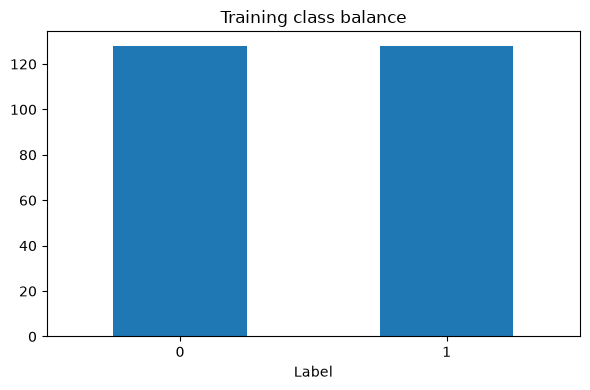

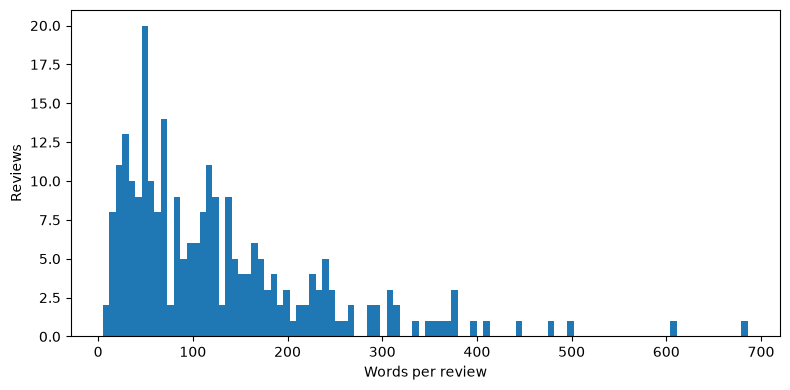

In [14]:
train_clean["raw_word_count"] = train_clean["text"].str.split().str.len()
test_clean["raw_word_count"] = test_clean["text"].str.split().str.len()
class_summary = pd.DataFrame({
    "Training count": train_clean["label"].value_counts().sort_index(),
    "Test count": test_clean["label"].value_counts().sort_index()
})
display(class_summary)
display(train_clean["raw_word_count"].describe(percentiles=[.5, .75, .9, .95, .99]))
class_summary["Training count"].plot.bar(figsize=(6, 4), rot=0, title="Training class balance")
plt.xlabel("Label")
plt.tight_layout()
plt.savefig(session["outputs"] / "class_balance.png", dpi=150)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(train_clean["raw_word_count"], bins=100)
plt.xlabel("Words per review")
plt.ylabel("Reviews")
plt.tight_layout()
plt.savefig(session["outputs"] / "review_lengths.png", dpi=150)
plt.show()


In [15]:
train_split, val_split = train_test_split(
    train_clean, test_size=PREPROCESSING["validation_fraction"],
    random_state=PREPROCESSING["seed"], stratify=train_clean["label"]
)
train_split = train_split.reset_index(drop=True)
val_split = val_split.reset_index(drop=True)
assert set(train_split["text_hash"]).isdisjoint(val_split["text_hash"])
assert set(train_split["text_hash"]).isdisjoint(test_clean["text_hash"])
assert set(val_split["text_hash"]).isdisjoint(test_clean["text_hash"])
print("Working train / validation / test:", len(train_split), len(val_split), len(test_clean))


Working train / validation / test: 230 26 64


### 2.2 Text processing and vocabulary

Lowercase, normalize negation contractions and whitespace, remove punctuation,
and remove stopwords while preserving negation/contrast words. No stemming,
lemmatization or pretrained embeddings are used. Only the training split
supplies the vocabulary. Empty processed reviews stay in the dataset and
receive one UNK token.


In [16]:
# Keep negation and contrast words when removing stopwords.
PRESERVE_WORDS = set(PREPROCESSING["preserved_words"])
STOP_WORDS = set(ENGLISH_STOP_WORDS) - PRESERVE_WORDS
print("Number of stopwords used:", len(STOP_WORDS))

def preprocess_text(text):
    # Lowercase
    text = text.lower().replace("\u2019", "'").replace("\u2018", "'")

    # Normalize important negation contractions
    text = re.sub(r"\bcan't\b", "can not", text)
    text = re.sub(r"\bwon't\b", "will not", text)
    text = re.sub(r"n['’]t\b", " not", text)

    # Remove punctuation and special characters
    # Keep letters, digits, and whitespace
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    # Token-level stopword removal
    tokens = [
        token
        for token in text.split()
        if token not in STOP_WORDS
    ]

    return " ".join(tokens)


Number of stopwords used: 310


In [17]:
tqdm.pandas()
for frame in (train_split, val_split, test_clean):
    frame["processed_text"] = frame["text"].progress_apply(preprocess_text)
    frame["token_count"] = frame["processed_text"].str.split().str.len()
display(train_split[["text", "processed_text", "label"]].head())
print("Empty processed train / validation / test:",
      *[int((frame["token_count"] == 0).sum()) for frame in (train_split, val_split, test_clean)])
if RUN_FORMAL_TRAINING:
    assert len(test_clean) == PREPROCESSING["expected_test_rows"]


100%|██████████| 64/64 [00:00<00:00, 10540.94it/s]


,text,processed_text,label
0,We took our dog here recently to get her annua...,took dog recently annual exam heartworm medica...,1
1,Want to try a new place to have a decent burri...,want try new place decent burrito watching mak...,0
2,"Good selection, but the food was rather boring...",good selection but food boring ate not food co...,0
3,It is really important to review something for...,really important review place amazing looking ...,1
4,I am changing my rating from 4 stars to 1 star...,changing rating 4 stars 1 star experience stax...,0


Empty processed train / validation / test: 0 0 0


In [18]:
def tokenize(text):
    return text.split()


MAX_VOCAB_SIZE = PREPROCESSING["max_vocab_size"]
MIN_FREQ = PREPROCESSING["min_frequency"]
token_counter = Counter()
for text in tqdm(train_split["processed_text"], desc="Building vocabulary"):
    token_counter.update(tokenize(text))

PAD_TOKEN, UNK_TOKEN = "<PAD>", "<UNK>"
itos = [PAD_TOKEN, UNK_TOKEN]
for token, frequency in token_counter.most_common():
    if frequency < MIN_FREQ or len(itos) >= MAX_VOCAB_SIZE:
        break
    itos.append(token)
stoi = {token: index for index, token in enumerate(itos)}
PAD_IDX, UNK_IDX = stoi[PAD_TOKEN], stoi[UNK_TOKEN]
VOCAB_SIZE = len(itos)
print("Vocabulary size:", VOCAB_SIZE, "| Embedding dimension:", EMBEDDING_DIM)
print("Common tokens:", token_counter.most_common(10))
display(train_split["token_count"].describe(percentiles=[.5, .75, .9, .95, .99]))
print(f"Training reviews covered by {MAX_LEN} tokens: {(train_split['token_count'] <= MAX_LEN).mean():.2%}")


Building vocabulary: 100%|██████████| 230/230 [00:00<00:00, 76459.53it/s]


Vocabulary size: 1767 | Embedding dimension: 128
Common tokens: [('not', 421), ('n', 336), ('but', 226), ('food', 165), ('s', 147), ('place', 145), ('salty', 131), ('good', 130), ('like', 100), ('very', 96)]


count    230.000000
mean      65.195652
std       54.665166
min        4.000000
50%       51.000000
75%       86.750000
90%      133.600000
95%      180.550000
99%      252.710000
max      330.000000
Name: token_count, dtype: float64

Training reviews covered by 192 tokens: 97.39%


In [19]:
def numericalize(text):
    token_ids = [stoi.get(token, UNK_IDX) for token in tokenize(text)]
    return token_ids or [UNK_IDX]


def encode_text(text, max_len=MAX_LEN):
    token_ids = numericalize(text)[:max_len]
    return token_ids + [PAD_IDX] * (max_len - len(token_ids))


### 2.3 Saved inputs and loaders

Save sample IDs, processed splits, vocabulary and configuration together.
Encode inputs once and read them through a memory map, instead of repeatedly
tokenizing during training. All three models share the same inputs and
shuffle seed. Zero worker processes keep the loaders usable in local notebooks.


In [20]:
def cache_inputs(frame, encode, length, path):
    ids = np.lib.format.open_memmap(path, mode="w+", dtype=np.int32, shape=(len(frame), length))
    for index, text in enumerate(frame["processed_text"]):
        ids[index] = encode(text, max_len=length)
    ids.flush()
    del ids


def preprocessing_record(session, config, raw_paths, frames, vocabulary, audit):
    paths = list(session["processed"].glob("*.parquet")) + [session["processed"] / "vocab.json"]
    split_ids = {name: frame["sample_id"].tolist() for name, frame in frames.items()}
    identity = {
        "raw_files": {path.name: file_hash(path) for path in raw_paths},
        "config": config,
        "vocabulary": vocabulary,
        "split_ids": split_ids,
        "processed_text_hashes": {
            name: hashlib.sha256("\n".join(frame["processed_text"]).encode("utf-8")).hexdigest()
            for name, frame in frames.items()
        },
    }
    fingerprint = hashlib.sha256(json.dumps(identity, sort_keys=True, ensure_ascii=False).encode("utf-8")).hexdigest()
    save_json(session["processed"] / "split_ids.json", split_ids)
    record = {
        "session_id": session["id"], "mode": session["mode"], "fingerprint": fingerprint,
        "dataset": config["dataset"], "raw_files": identity["raw_files"], "config": config,
        "rows": {name: len(frame) for name, frame in frames.items()}, "cleaning": audit,
        "artifacts": {path.relative_to(session["root"]).as_posix(): file_hash(path) for path in paths},
        "split_ids": (session["processed"] / "split_ids.json").relative_to(session["root"]).as_posix(),
    }
    save_json(session["manifests"] / "preprocessing.json", record)
    session["data_fingerprint"] = fingerprint
    return record


In [21]:
saved_columns = ["sample_id", "text", "processed_text", "label",
                 "raw_word_count", "token_count", "text_hash"]
for name, frame in (("train", train_split), ("val", val_split), ("test", test_clean)):
    frame[saved_columns].to_parquet(ARTIFACT_DIR / (name + "_processed.parquet"), index=False)
vocab_data = {
    "itos": itos, "pad_token": PAD_TOKEN, "unk_token": UNK_TOKEN,
    "pad_idx": PAD_IDX, "unk_idx": UNK_IDX, "vocab_size": VOCAB_SIZE
}
save_json(ARTIFACT_DIR / "vocab.json", vocab_data)

preprocessing_config = {
    **PREPROCESSING,
    "stop_words": sorted(STOP_WORDS),
    "empty_text_encoding": "UNK",
    "embedding_dim": EMBEDDING_DIM,
    "pretrained_embeddings": False,
    "labels": {"0": "negative", "1": "positive"}
}
save_json(ARTIFACT_DIR / "preprocessing_config.json", preprocessing_config)
preprocessing_manifest = preprocessing_record(
    session, preprocessing_config, [train_path, test_path],
    {"train": train_split, "validation": val_split, "test": test_clean},
    vocab_data, data_audit
)
length_bounds = train_split["raw_word_count"].quantile(
    EVALUATION["length_slice_quantiles"]
).to_numpy()
print("Vocabulary, configuration and split identities saved.")


Vocabulary, configuration and split identities saved.


In [22]:
from torch.utils.data import Dataset, DataLoader


class YelpDataset(Dataset):
    def __init__(self, dataframe, cache_path, max_len=MAX_LEN):
        cache_inputs(dataframe, encode_text, max_len, cache_path)
        self.input_ids = np.load(cache_path, mmap_mode="r")
        self.labels = dataframe["label"].to_numpy(dtype=np.float32)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        input_ids = torch.from_numpy(self.input_ids[index].astype(np.int64))
        label = torch.tensor(self.labels[index], dtype=torch.float32)
        return input_ids, label


train_dataset = YelpDataset(train_split, ARTIFACT_DIR / "train_ids.npy")
val_dataset = YelpDataset(val_split, ARTIFACT_DIR / "val_ids.npy")
test_dataset = YelpDataset(test_clean, ARTIFACT_DIR / "test_ids.npy")
for path in ARTIFACT_DIR.glob("*_ids.npy"):
    preprocessing_manifest["artifacts"][path.relative_to(PROJECT_ROOT).as_posix()] = file_hash(path)
save_json(session["manifests"] / "preprocessing.json", preprocessing_manifest)
print("Training examples:", len(train_dataset))
print("Validation examples:", len(val_dataset))
print("Test examples:", len(test_dataset))


Training examples: 230
Validation examples: 26
Test examples: 64


In [23]:
BATCH_SIZE = TRAINING["batch_size" if RUN_FORMAL_TRAINING else "smoke_batch_size"]
loader_generator = torch.Generator().manual_seed(SEED)
active_training = {
    "seed": SEED, "batch_size": BATCH_SIZE,
    "learning_rate": TRAINING["learning_rate"],
    "epochs": TRAINING["epochs"] if RUN_FORMAL_TRAINING else 1,
    "patience": TRAINING["patience"],
    "max_batches": None if RUN_FORMAL_TRAINING else TRAINING["smoke_max_batches"],
    "gradient_clip": None,
    "decision_threshold": THRESHOLD,
}

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=TRAINING["num_workers"],
    pin_memory=device.type == "cuda",
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=TRAINING["num_workers"],
    pin_memory=device.type == "cuda"
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=TRAINING["num_workers"],
    pin_memory=device.type == "cuda"
)


batch_input_ids, batch_labels = next(iter(train_loader))
assert batch_input_ids.shape[1] == MAX_LEN
assert batch_input_ids.min() >= 0 and batch_input_ids.max() < VOCAB_SIZE
assert batch_labels.dtype == torch.float32
print("Batch inputs / labels:", batch_input_ids.shape, batch_labels.shape)


Batch inputs / labels: torch.Size([16, 192]) torch.Size([16])


## 3. Model definitions

The three models keep their original architecture. All output one logit and
use BCEWithLogitsLoss. Embeddings are trainable and initialized from scratch.
Formal defaults are 128-dimensional embeddings, length 192 and up to 50,000
vocabulary entries.


### 3.1 Baseline — mean-pooled embeddings


The baseline converts each review into the mean of its trainable word
embeddings and uses this representation for binary sentiment classification.

Its main advantage is simplicity and computational efficiency. However,
mean pooling removes explicit word-order information. For example, reviews
containing similar words in different contexts may receive similar
representations.

This limitation provides motivation for the experimental models, which will
introduce local feature extraction and sequential context modeling.


In [24]:
class MeanPoolClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        pad_idx,
        dropout=0.3
    ):
        super().__init__()

        self.pad_idx = pad_idx

        # Trainable embeddings learned from scratch
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.dropout = nn.Dropout(dropout)

        # One output logit for binary classification
        self.fc = nn.Linear(
            embedding_dim,
            1
        )

    def forward(self, input_ids):
        # input_ids:
        # [batch_size, sequence_length]

        embedded = self.embedding(input_ids)
        # [batch_size, sequence_length, embedding_dim]

        # Mask padding tokens
        mask = (
            input_ids != self.pad_idx
        ).unsqueeze(-1).float()
        # [batch_size, sequence_length, 1]

        # Sum only valid token embeddings
        summed_embeddings = (
            embedded * mask
        ).sum(dim=1)
        # [batch_size, embedding_dim]

        # Number of valid tokens in each review
        token_counts = (
            mask.sum(dim=1)
            .clamp(min=1)
        )
        # [batch_size, 1]

        # Mean pooling
        pooled = (
            summed_embeddings / token_counts
        )
        # [batch_size, embedding_dim]

        pooled = self.dropout(pooled)

        logits = self.fc(pooled).squeeze(1)
        # [batch_size]

        return logits


### 3.2 TextCNN


The TextCNN model is used as the first experimental architecture because
sentiment is often expressed through short local phrases such as
"highly recommend", "not worth it", or "very poor service".

Unlike the baseline model, which averages word embeddings and therefore loses
explicit word-order information, convolutional filters can detect local
patterns across neighboring tokens.

Using multiple kernel sizes allows the model to capture phrase patterns of
different lengths. Global max pooling then retains the strongest feature
detected by each convolutional filter.

#### TextCNN Architecture Summary

TextCNN extends the baseline by explicitly modeling local word-order patterns.

Parallel convolutional filters with kernel sizes 3, 4, and 5 extract local
phrase-level features from the trainable word embeddings. Global max pooling
selects the strongest activation from each filter, and the resulting features
are concatenated for final sentiment classification.

This architecture is expected to capture local sentiment expressions that the
mean-pooled baseline cannot explicitly represent.


In [25]:
class TextCNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        pad_idx,
        num_filters=128,
        kernel_sizes=(3, 4, 5),
        dropout=0.5
    ):
        super().__init__()
        self.pad_idx = pad_idx

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embedding_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(
            num_filters * len(kernel_sizes),
            1
        )

    def forward(self, input_ids):
        # input_ids:
        # [batch_size, sequence_length]

        lengths = (input_ids != self.pad_idx).sum(dim=1).clamp(min=1)
        embedded = self.embedding(input_ids)
        # [batch_size, sequence_length, embedding_dim]

        embedded = embedded.transpose(1, 2)
        # [batch_size, embedding_dim, sequence_length]

        pooled_outputs = []

        for conv in self.convs:

            features = torch.relu(
                conv(embedded)
            )
            # [batch_size, num_filters, new_sequence_length]

            # Exclude padding-only windows. Very short reviews use one window.
            valid_windows = (lengths - conv.kernel_size[0] + 1).clamp(min=1)
            positions = torch.arange(features.size(2), device=input_ids.device)
            valid = positions.unsqueeze(0) < valid_windows.unsqueeze(1)
            features = features.masked_fill(~valid.unsqueeze(1), float("-inf"))

            pooled = torch.max(
                features,
                dim=2
            ).values
            # [batch_size, num_filters]

            pooled_outputs.append(pooled)

        combined = torch.cat(
            pooled_outputs,
            dim=1
        )
        # [batch_size, num_filters * number_of_kernel_sizes]

        combined = self.dropout(combined)

        logits = self.fc(combined).squeeze(1)
        # [batch_size]

        return logits


### 3.3 BiLSTM


The BiLSTM is used as the second experimental architecture to test whether
longer-range sequential context improves sentiment classification.

The baseline model aggregates word embeddings without explicitly modeling word
order. TextCNN captures local patterns through convolutional filters, but its
features mainly focus on relatively short token windows.

BiLSTM processes the entire token sequence in both forward and backward
directions. This makes it better suited for sentiment expressions whose
interpretation depends on context across a longer portion of the review.

Packed sequences are used so that padding tokens do not influence the final
forward and backward hidden-state representations.

#### BiLSTM Architecture Summary

The BiLSTM extends the previous models by explicitly modeling sequential
dependencies in both directions.

The forward and backward final hidden states are concatenated to create a
context-aware representation of each review. Packed sequences are used to
prevent padding tokens from affecting the recurrent representation.

The model therefore tests whether longer-range bidirectional context provides
additional sentiment information beyond mean pooling and local convolutional
features.


In [26]:
# BiLSTM Model
from torch.nn.utils.rnn import pack_padded_sequence


class BiLSTMClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        pad_idx,
        num_layers=1,
        dropout=0.4
    ):
        super().__init__()

        self.pad_idx = pad_idx

        # Trainable embeddings learned from scratch
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=pad_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(
            dropout
        )

        # Forward + backward hidden states
        self.fc = nn.Linear(
            hidden_dim * 2,
            1
        )

    def forward(self, input_ids):

        # input_ids:
        # [batch_size, sequence_length]

        lengths = (
            input_ids != self.pad_idx
        ).sum(dim=1)

        # Safety check in case an empty sequence appears
        lengths = lengths.clamp(min=1)

        embedded = self.embedding(
            input_ids
        )
        # [batch_size, sequence_length, embedding_dim]

        packed = pack_padded_sequence(
            embedded,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (hidden, _) = self.lstm(
            packed
        )

        # For one-layer bidirectional LSTM:
        #
        # hidden[-2] = final forward hidden state
        # hidden[-1] = final backward hidden state

        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        combined_hidden = torch.cat(
            (
                forward_hidden,
                backward_hidden
            ),
            dim=1
        )
        # [batch_size, hidden_dim * 2]

        combined_hidden = self.dropout(
            combined_hidden
        )

        logits = self.fc(
            combined_hidden
        ).squeeze(1)

        return logits


## 4. Shared training and evaluation

Each model uses these same functions. This keeps the model sections short and
makes the metric definitions consistent. Defaults: Adam 0.001, batch size 256,
at most five epochs, and early-stopping patience two. BiLSTM clips gradients
at norm 1. Checkpoint selection uses validation loss only.


### 4.1 Training one epoch and checking validation loss


In [27]:
def train_one_epoch(model, loader, criterion, optimizer, device,
                    max_batches=None, max_grad_norm=None, log_step=None):
    model.train()
    running_loss = correct = total = 0
    gradient_norms = []
    synchronize(device)
    started = time.perf_counter()

    for batch, (input_ids, labels) in enumerate(loader, start=1):
        if max_batches is not None and batch > max_batches:
            break
        input_ids = input_ids.to(device, non_blocking=device.type == "cuda")
        labels = labels.to(device, non_blocking=device.type == "cuda")
        optimizer.zero_grad(set_to_none=True)
        logits = model(input_ids)
        loss = criterion(logits, labels)
        if not torch.isfinite(loss):
            raise FloatingPointError("Non-finite training loss.")
        loss.backward()
        gradient_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            float("inf") if max_grad_norm is None else max_grad_norm,
            error_if_nonfinite=True
        ).item()
        optimizer.step()

        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        predictions = (torch.sigmoid(logits.detach()) >= THRESHOLD).float()
        correct += (predictions == labels).sum().item()
        total += batch_size
        gradient_norms.append(gradient_norm)
        if log_step is not None:
            log_step(batch=batch, loss=loss.item(), examples=batch_size,
                     gradient_norm_before_clip=gradient_norm)

    synchronize(device)
    elapsed = time.perf_counter() - started
    if total == 0:
        raise ValueError("The training loader is empty.")
    return {
        "loss": running_loss / total, "accuracy": correct / total,
        "time_seconds": elapsed, "examples_per_second": total / elapsed,
        "examples": total, "gradient_norm_mean": float(np.mean(gradient_norms)),
        "gradient_norm_max": float(max(gradient_norms))
    }


def evaluate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = correct = total = 0
    synchronize(device)
    started = time.perf_counter()
    with torch.no_grad():
        for input_ids, labels in loader:
            input_ids = input_ids.to(device, non_blocking=device.type == "cuda")
            labels = labels.to(device, non_blocking=device.type == "cuda")
            logits = model(input_ids)
            loss = criterion(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError("Non-finite validation loss.")
            running_loss += loss.item() * labels.size(0)
            predictions = (torch.sigmoid(logits) >= THRESHOLD).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    synchronize(device)
    if total == 0:
        raise ValueError("The validation loader is empty.")
    return {"loss": running_loss / total, "accuracy": correct / total,
            "time_seconds": time.perf_counter() - started}


### 4.2 Training records and checkpoints

The shared loop records per-batch losses and gradient norms, epoch summaries,
timing, memory and hardware. It writes best.pt for evaluation and last.pt for
resume. Numbered best checkpoints keep recovery possible if a save is interrupted.
RESUME_CHECKPOINTS can reuse completed models or resume an interrupted model
after its last complete epoch; previous raw logs remain unchanged.


In [28]:
def run_training(name, model, model_config, gradient_clip=None):
    config = {**active_training, "gradient_clip": gradient_clip}
    vocabulary, preprocessing = vocab_data, preprocessing_config
    resume_checkpoint = RESUME_CHECKPOINTS.get(name)
    model.to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    root = session["root"]
    run_id = session["id"] + "_" + name
    output_dir = session["outputs"] / name
    checkpoint_dir = session["checkpoints"] / name
    output_dir.mkdir()
    checkpoint_dir.mkdir()
    best_path = checkpoint_dir / "best.pt"
    best_epoch_path = None
    last_path = checkpoint_dir / "last.pt"
    manifest_path = session["manifests"] / (name + ".json")
    raw_log = session["logs"] / (run_id + ".jsonl")
    record = {
        "run_id": run_id, "model_name": name, "mode": session["mode"], "status": "running",
        "model_config": model_config, "training_config": config,
        "hardware": hardware_info(device), "data_fingerprint": session["data_fingerprint"],
        "preprocessing_manifest": (session["manifests"] / "preprocessing.json").relative_to(root).as_posix(),
        "source_hashes": session["source_hashes"],
        "raw_log": raw_log.relative_to(root).as_posix(),
        "output_dir": output_dir.relative_to(root).as_posix(),
        "best_checkpoint": best_path.relative_to(root).as_posix(),
        "last_checkpoint": last_path.relative_to(root).as_posix(),
        "resume_from": resume_checkpoint,
    }
    history = []
    best_loss = float("inf")
    best_epoch = patience_count = 0
    start_epoch = 1
    previous_wall_seconds = 0.0
    if resume_checkpoint:
        previous = torch.load(root / resume_checkpoint, map_location="cpu", weights_only=True)
        for key, expected in (("model_config", model_config), ("training_config", config),
                              ("data_fingerprint", session["data_fingerprint"]),
                              ("source_hashes", session["source_hashes"])):
            if previous[key] != expected:
                raise ValueError(f"Resume {key} differs from the saved run.")
        model.load_state_dict(previous["model_state_dict"])
        optimizer.load_state_dict(previous["optimizer_state_dict"])
        history = previous["history"]
        best_loss, best_epoch = previous["best_val_loss"], previous["best_epoch"]
        patience_count = previous["patience_count"]
        start_epoch = previous["epoch"] + 1
        previous_wall_seconds = previous["wall_seconds_to_checkpoint"]
        if start_epoch > config["epochs"] or patience_count >= config["patience"]:
            # A completed model can be reused while an interrupted companion resumes.
            start_epoch = config["epochs"] + 1
        previous_best = root / previous["best_checkpoint"]
        if file_hash(previous_best) != previous["best_checkpoint_sha256"]:
            raise ValueError("The previous best checkpoint is missing or changed.")
        best_epoch_path = checkpoint_dir / previous_best.name
        copy_checkpoint(previous_best, best_epoch_path)
        copy_checkpoint(best_epoch_path, best_path)
        torch.set_rng_state(previous["torch_rng_state"])
        if previous["device_type"] == device.type:
            if device.type == "cuda":
                torch.cuda.set_rng_state(previous["device_rng_state"], device)
            elif device.type == "mps":
                torch.mps.set_rng_state(previous["device_rng_state"])
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
    memory = memory_usage(device)
    save_json(manifest_path, record)
    synchronize(device)
    started = time.perf_counter()

    with raw_log.open("x", encoding="utf-8", newline="\n") as log_file:
        def log(event, **values):
            log_file.write(json.dumps({"time_utc": datetime.now(timezone.utc).isoformat(),
                                       "event": event, **values}, allow_nan=False) + "\n")
            log_file.flush()

        def step_log(**values):
            log("train_step", epoch=epoch, **values)
            for key, value in memory_usage(device).items():
                memory[key] = max(memory.get(key, 0), value)

        log("run_start", **record)
        try:
            for epoch in range(start_epoch, config["epochs"] + 1):
                # Each model sees the same shuffle for a given epoch, regardless of run order.
                train_loader.generator.manual_seed(config["seed"] + epoch - 1)
                train = train_one_epoch(model, train_loader, criterion, optimizer, device,
                                    max_batches=config.get("max_batches"),
                                    max_grad_norm=config.get("gradient_clip"), log_step=step_log)
                valid = evaluate_epoch(model, val_loader, criterion, device)
                row = {
                    "epoch": epoch, "train_loss": train["loss"], "train_accuracy": train["accuracy"],
                    "val_loss": valid["loss"], "val_accuracy": valid["accuracy"],
                    "train_time_seconds": train["time_seconds"],
                    "train_examples_per_second": train["examples_per_second"],
                    "training_examples": train["examples"], "val_time_seconds": valid["time_seconds"],
                    "gradient_norm_mean": train["gradient_norm_mean"],
                    "gradient_norm_max": train["gradient_norm_max"],
                }
                history.append(row)
                improved = valid["loss"] < best_loss
                if improved:
                    best_loss, best_epoch, patience_count = valid["loss"], epoch, 0
                else:
                    patience_count += 1
                common = {
                    "run_id": run_id, "model_name": name, "mode": session["mode"], "epoch": epoch,
                    "model_config": model_config, "training_config": config,
                    "model_state_dict": model.state_dict(), "vocabulary": vocabulary,
                    "preprocessing": preprocessing, "data_fingerprint": session["data_fingerprint"],
                    "source_hashes": session["source_hashes"], "val_loss": valid["loss"],
                }
                if improved:
                    # Keep the checkpoint referenced by the last completed epoch intact.
                    best_epoch_path = checkpoint_dir / f"best_epoch_{epoch:03d}.pt"
                    save_checkpoint(best_epoch_path, common)
                    copy_checkpoint(best_epoch_path, best_path)
                state = {
                    **common, "optimizer_state_dict": optimizer.state_dict(), "history": history,
                    "best_val_loss": best_loss, "best_epoch": best_epoch, "patience_count": patience_count,
                    "best_checkpoint": best_epoch_path.relative_to(root).as_posix(),
                    "best_checkpoint_sha256": file_hash(best_epoch_path),
                    "torch_rng_state": torch.get_rng_state(), "device_type": device.type,
                    "device_rng_state": torch.cuda.get_rng_state(device) if device.type == "cuda" else (
                        torch.mps.get_rng_state() if device.type == "mps" else None),
                    "wall_seconds_to_checkpoint": previous_wall_seconds + time.perf_counter() - started,
                }
                save_checkpoint(last_path, state)
                pd.DataFrame(history).to_csv(output_dir / "history.csv", index=False)
                log("epoch_complete", **row, best_epoch=best_epoch)
                print(f"{name} | Epoch {epoch:02d} | Train {train['loss']:.4f} | "
                      f"Val {valid['loss']:.4f} | Val acc {valid['accuracy']:.4f}")
                if patience_count >= config["patience"]:
                    log("early_stopping", epoch=epoch, patience=patience_count)
                    break
            if not last_path.exists():
                # No epochs ran: retain a portable copy of the completed resume state.
                state = dict(previous)
                state["best_checkpoint"] = best_epoch_path.relative_to(root).as_posix()
                state["best_checkpoint_sha256"] = file_hash(best_epoch_path)
                save_checkpoint(last_path, state)
                pd.DataFrame(history).to_csv(output_dir / "history.csv", index=False)
            for key, value in memory_usage(device).items():
                memory[key] = max(memory.get(key, 0), value)
            synchronize(device)
            elapsed = time.perf_counter() - started
            training_seconds = sum(row["train_time_seconds"] for row in history)
            training_examples = sum(row["training_examples"] for row in history)
            summary = {
                "run_id": run_id, "model_name": name, "mode": session["mode"],
                "completed_epochs": len(history), "best_epoch": best_epoch,
                "best_validation_loss": best_loss,
                "parameter_count": sum(p.numel() for p in model.parameters() if p.requires_grad),
                "training_loop_seconds": training_seconds,
                "training_examples_per_second": training_examples / training_seconds,
                "training_wall_seconds_this_segment": elapsed, "memory": memory,
                "training_wall_seconds_including_resume": previous_wall_seconds + elapsed,
                "epochs_trained_this_segment": max(0, history[-1]["epoch"] - start_epoch + 1),
                "best_checkpoint": best_path.relative_to(root).as_posix(),
                "best_checkpoint_sha256": file_hash(best_path),
                "nonfinite_events": 0,
            }
            save_json(output_dir / "training_summary.json", summary)
            record.update(status="trained", summary=summary)
            save_json(manifest_path, record)
            log("training_complete", **summary)
        except BaseException as error:
            record["status"] = "interrupted" if isinstance(error, KeyboardInterrupt) else "failed"
            record["error"] = type(error).__name__ + ": " + str(error)
            save_json(manifest_path, record)
            log(record["status"], error=record["error"])
            raise
    return {**summary, "output_path": output_dir, "checkpoint_path": best_path,
            "manifest_path": manifest_path, "history": history}


In [29]:
def load_best(model, run, device):
    if file_hash(run["checkpoint_path"]) != run["best_checkpoint_sha256"]:
        raise ValueError("Best-checkpoint checksum mismatch.")
    checkpoint = torch.load(run["checkpoint_path"], map_location="cpu", weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device).eval()
    return checkpoint


In [30]:
def show_training(run):
    history = pd.DataFrame(run["history"])
    display(history)
    for metric, label, filename in (
        ("loss", "Loss", "loss_curve.png"),
        ("accuracy", "Accuracy", "accuracy_curve.png")
    ):
        plt.figure(figsize=(7, 4))
        plt.plot(history["epoch"], history["train_" + metric], marker="o", label="Train")
        plt.plot(history["epoch"], history["val_" + metric], marker="o", label="Validation")
        plt.xlabel("Epoch")
        plt.ylabel(label)
        plt.title(run["model_name"])
        plt.legend()
        plt.tight_layout()
        plt.savefig(run["output_path"] / filename, dpi=150)
        plt.show()
    print("Best epoch:", run["best_epoch"])
    print("Training examples/sec:", round(run["training_examples_per_second"], 2))
    print("Memory measurements:", run["memory"])


### 4.3 Metrics and uncertainty

Report accuracy, precision/recall/F1 (macro, micro, weighted), ROC-AUC, PR-AUC,
MCC, Brier score and ECE. PR-AUC uses trapezoidal area; average precision is
reported separately. ECE uses ten equal-width bins of predicted-class confidence.
The default threshold is 0.5. Formal bootstrap intervals use 1,000 paired row
resamples and the 2.5th/97.5th percentiles for accuracy, macro-F1 and MCC.


In [31]:
def collect_predictions(model, loader, device):
    model.eval()
    labels, probabilities = [], []
    with torch.no_grad():
        for input_ids, batch_labels in loader:
            logits = model(input_ids.to(device))
            labels.append(batch_labels.numpy())
            probabilities.append(torch.sigmoid(logits).cpu().numpy())
    y_true = np.concatenate(labels).astype(int)
    y_prob = np.concatenate(probabilities)
    if not np.isfinite(y_prob).all():
        raise FloatingPointError("Non-finite test probabilities.")
    return y_true, y_prob, (y_prob >= THRESHOLD).astype(int)


def classification_metrics(y_true, y_pred, y_prob):
    result = {"accuracy": accuracy_score(y_true, y_pred)}
    for average in ("macro", "micro", "weighted"):
        precision, recall, f1, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], average=average, zero_division=0
        )
        result.update({f"precision_{average}": precision, f"recall_{average}": recall,
                       f"f1_{average}": f1})
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    result.update({
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": auc(recall, precision),
        "average_precision": average_precision_score(y_true, y_prob),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob)
    })
    return result


def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true, y_prob = np.asarray(y_true), np.asarray(y_prob)
    y_pred = (y_prob >= THRESHOLD).astype(int)
    confidence = np.where(y_pred == 1, y_prob, 1 - y_prob)
    correct = y_pred == y_true
    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for index in range(n_bins):
        in_bin = (confidence <= edges[index + 1]) & (
            (confidence >= edges[index]) if index == 0 else (confidence > edges[index])
        )
        if in_bin.any():
            ece += in_bin.mean() * abs(correct[in_bin].mean() - confidence[in_bin].mean())
    return float(ece)


In [32]:
def bootstrap_confidence_intervals(y_true, y_pred, n_bootstrap=1000, seed=SEED):
    y_true = np.asarray(y_true, dtype=int)
    y_pred = np.asarray(y_pred, dtype=int)
    if not len(y_true) or len(y_true) != len(y_pred) or n_bootstrap < 1:
        raise ValueError("Bootstrap needs paired, nonempty predictions and positive resamples.")
    rng = np.random.default_rng(seed)
    values = np.empty((n_bootstrap, 3))
    n = len(y_true)
    for index in range(n_bootstrap):
        rows = rng.integers(0, n, size=n)
        tn, fp, fn, tp = np.bincount(
            2 * y_true[rows] + y_pred[rows], minlength=4
        ).astype(float)
        f1_negative = 2 * tn / (2 * tn + fp + fn) if 2 * tn + fp + fn else 0.0
        f1_positive = 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0
        denominator = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
        mcc = (tp * tn - fp * fn) / denominator if denominator else 0.0
        values[index] = ((tn + tp) / n, (f1_negative + f1_positive) / 2, mcc)
    bounds = np.percentile(values, [2.5, 97.5], axis=0)
    return {key: tuple(bounds[:, index]) for index, key in enumerate(
        ("accuracy_ci", "macro_f1_ci", "mcc_ci")
    )}


### 4.4 Slices, error examples and saved evaluation

Length cutoffs are fitted on training reviews. Other slices measure negation,
truncation and empty processed text. Save predictions with sample IDs so
paired comparisons cannot silently use mismatched rows.

Each model exports up to 20 distinct errors across confident false positives,
confident false negatives, near-threshold errors and long-review/negation
failures. Review the text and fill error_type, observation and testable_fix.
Shortages are recorded explicitly; exporting candidates is not completed analysis.


In [33]:
def review_slices(frame, bounds, max_length):
    lengths = frame["raw_word_count"].to_numpy()
    negation = frame["text"].str.contains(
        r"\b(?:no|not|never|nor|cannot)\b|n['’]t\b", case=False, regex=True
    ).to_numpy()
    return {
        "length_short": lengths <= bounds[0],
        "length_medium": (lengths > bounds[0]) & (lengths <= bounds[1]),
        "length_long": lengths > bounds[1],
        "has_negation": negation,
        "no_negation": ~negation,
        "truncated": frame["token_count"].to_numpy() > max_length,
        "not_truncated": frame["token_count"].to_numpy() <= max_length,
        "empty_after_preprocessing": frame["token_count"].to_numpy() == 0,
    }


def slice_scores(y_true, y_pred, masks):
    rows = []
    for name, mask in masks.items():
        count = int(mask.sum())
        rows.append({
            "slice": name, "count": count,
            "negative_examples": int((y_true[mask] == 0).sum()),
            "positive_examples": int((y_true[mask] == 1).sum()),
            "macro_f1": float(f1_score(y_true[mask], y_pred[mask], labels=[0, 1],
                                     average="macro", zero_division=0)) if count else None,
            "error_rate": float((y_true[mask] != y_pred[mask]).mean()) if count else None,
        })
    return pd.DataFrame(rows)


def error_candidates(frame, y_true, y_prob, y_pred, masks, count, threshold=0.5):
    errors = frame.copy().reset_index(drop=True)
    errors["true_label"] = y_true
    errors["predicted_label"] = y_pred
    errors["positive_probability"] = y_prob
    errors["confidence"] = np.where(y_pred == 1, y_prob, 1 - y_prob)
    errors["distance_from_threshold"] = np.abs(y_prob - threshold)
    wrong = y_true != y_pred
    categories = {
        "confident_false_positive": wrong & (y_true == 0),
        "confident_false_negative": wrong & (y_true == 1),
        "near_threshold": wrong,
        "slice_specific": wrong & (masks["length_long"] | masks["has_negation"]),
    }
    chosen, selected, shortages = [], set(), {}
    for category, mask in categories.items():
        eligible = errors.loc[mask & ~errors.index.isin(selected)]
        column = "distance_from_threshold" if category == "near_threshold" else "confidence"
        eligible = eligible.sort_values(column, ascending=category == "near_threshold", kind="stable").head(count)
        selected.update(eligible.index)
        eligible = eligible.copy()
        eligible["category"] = category
        eligible["slice"] = [
            ";".join(name for name in ("length_long", "has_negation") if masks[name][index])
            for index in eligible.index
        ]
        eligible["error_type"] = ""
        eligible["observation"] = ""
        eligible["testable_fix"] = ""
        chosen.append(eligible)
        shortages[category] = count - len(eligible)
    return pd.concat(chosen, ignore_index=True), shortages


In [34]:
def save_evaluation(run, session, frame, y_true, y_prob, y_pred, metrics,
                    confusion, intervals, evaluation_config, length_bounds, max_length):
    if not np.array_equal(frame["label"].to_numpy(), y_true):
        raise ValueError("Test labels and prediction rows are misaligned.")
    if not frame["sample_id"].is_unique:
        raise ValueError("Test sample IDs must be unique.")
    if len(y_prob) != len(frame) or not np.isfinite(y_prob).all():
        raise ValueError("Invalid prediction probabilities.")
    if not np.all((0 <= y_prob) & (y_prob <= 1)):
        raise ValueError("Probabilities must be between zero and one.")
    if not np.array_equal(y_pred, (y_prob >= evaluation_config["threshold"]).astype(int)):
        raise ValueError("Predictions do not use the configured threshold.")
    output = run["output_path"]
    predictions = pd.DataFrame({
        "sample_id": frame["sample_id"].to_numpy(), "label": y_true,
        "probability_positive": y_prob, "prediction": y_pred,
    })
    predictions.to_csv(output / "predictions.csv", index=False)
    masks = review_slices(frame, length_bounds, max_length)
    slices = slice_scores(y_true, y_pred, masks)
    slices.to_csv(output / "slice_metrics.csv", index=False)
    candidates, shortages = error_candidates(
        frame, y_true, y_prob, y_pred, masks, evaluation_config["errors_per_category"],
        evaluation_config["threshold"]
    )
    candidates.to_csv(output / "error_review.csv", index=False)
    save_json(output / "error_review_status.json", {
        "status": "manual_review_pending", "required_per_category": evaluation_config["errors_per_category"],
        "available_rows": len(candidates), "shortages": shortages,
        "selection": "Distinct wrong predictions; confidence extremes, closest to the fixed threshold, and predefined long/negation slices.",
        "note": "Confidence is ranked, not required to exceed a fixed threshold. No errors are invented to fill a category.",
    })
    result = {
        "run_id": run["run_id"], "mode": session["mode"], "test_rows": len(frame),
        "metrics": {key: float(value) for key, value in metrics.items()},
        "confusion_matrix": np.asarray(confusion).tolist(),
        "confidence_intervals": {key: [float(v) for v in value] for key, value in intervals.items()},
        "protocol": {**evaluation_config, "length_bounds_from_training": [float(v) for v in length_bounds],
                     "max_length": max_length, "pr_auc": "trapezoidal area under precision-recall curve",
                     "average_precision": "non-interpolated average precision; reported separately",
                     "ece": "equal-width confidence bins, predicted-class confidence",
                     "bootstrap": "IID paired row resampling; percentile intervals"},
        "checkpoint": run["best_checkpoint"], "checkpoint_sha256": run["best_checkpoint_sha256"],
        "predictions_sha256": file_hash(output / "predictions.csv"),
    }
    save_json(output / "evaluation.json", result)
    manifest = json.loads(run["manifest_path"].read_text(encoding="utf-8"))
    manifest.update(status="complete", evaluation=(output / "evaluation.json").relative_to(session["root"]).as_posix())
    save_json(run["manifest_path"], manifest)
    return {**result, "run": run, "predictions": predictions, "slices": slices}


In [35]:
def evaluate_model(model, run):
    load_best(model, run, device)
    y_true, y_prob, y_pred = collect_predictions(model, test_loader, device)
    metrics = classification_metrics(y_true, y_pred, y_prob)
    metrics["ece"] = expected_calibration_error(y_true, y_prob, EVALUATION["ece_bins"])
    confusion = confusion_matrix(y_true, y_pred, labels=[0, 1])
    intervals = bootstrap_confidence_intervals(
        y_true, y_pred, n_bootstrap=N_BOOTSTRAP, seed=EVALUATION["bootstrap_seed"]
    )
    result = save_evaluation(
        run, session, test_clean, y_true, y_prob, y_pred, metrics, confusion, intervals,
        {**EVALUATION, "bootstrap_resamples": N_BOOTSTRAP}, length_bounds, MAX_LEN
    )
    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(confusion)
    ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="Predicted label", ylabel="True label",
           title=run["model_name"] + " confusion matrix")
    for row in range(2):
        for column in range(2):
            ax.text(column, row, confusion[row, column], ha="center", va="center")
    plt.tight_layout()
    plt.savefig(run["output_path"] / "confusion_matrix.png", dpi=150)
    plt.show()
    display(pd.DataFrame(metrics.items(), columns=["Metric", "Value"]))
    display(pd.DataFrame(intervals, index=["95% lower", "95% upper"]).T)
    model.to("cpu")
    return result


## 5. Train the three models

These sections differ only in architecture, dropout and BiLSTM gradient clipping.
The initial seed, data, optimizer settings and evaluation protocol are shared.
Smoke runs check execution; their scores are not final Yelp results.


### 5.1 baseline

Mean-pooled embeddings provide the simple reference model.


MeanPoolClassifier(
  (embedding): Embedding(1767, 128, padding_idx=0)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
baseline | Epoch 01 | Train 0.6937 | Val 0.7048 | Val acc 0.5000


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,train_time_seconds,train_examples_per_second,training_examples,val_time_seconds,gradient_norm_mean,gradient_norm_max
0,1,0.693668,0.645833,0.704758,0.5,0.171574,279.76332,48,0.001344,0.467675,0.733053


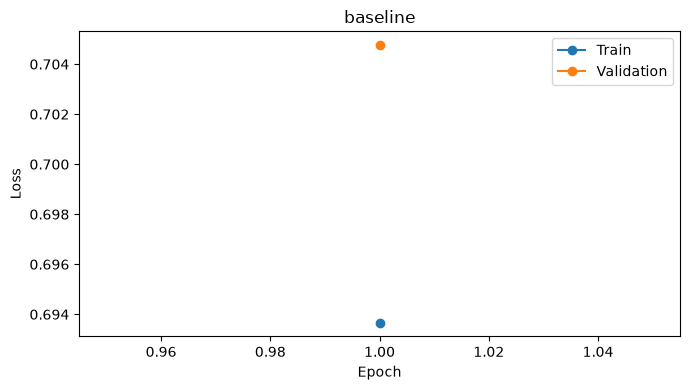

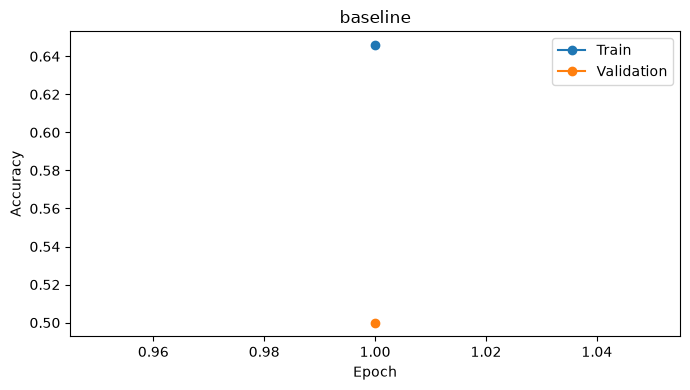

Best epoch: 1
Training examples/sec: 279.76
Memory measurements: {'process_lifetime_peak_rss_bytes': 3162132480, 'cuda_peak_allocated_bytes': 24640000}


In [36]:
seed_everything(SEED)
baseline_config = {
    "vocab_size": VOCAB_SIZE, "embedding_dim": EMBEDDING_DIM, "pad_idx": PAD_IDX,
    "dropout": MODELS["baseline"]["dropout"]
}
baseline_model = MeanPoolClassifier(**baseline_config)
print(baseline_model)
baseline_run = run_training("baseline", baseline_model, baseline_config)
show_training(baseline_run)


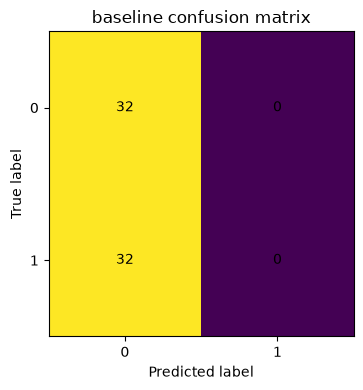

,Metric,Value
0,accuracy,0.500000
1,precision_macro,0.250000
2,recall_macro,0.500000
3,f1_macro,0.333333
4,precision_micro,0.500000
5,recall_micro,0.500000
6,f1_micro,0.500000
7,precision_weighted,0.250000
8,recall_weighted,0.500000
9,f1_weighted,0.333333


,95% lower,95% upper
accuracy_ci,0.421875,0.605859
macro_f1_ci,0.296703,0.377270
mcc_ci,0.000000,0.000000


In [37]:
baseline_evaluation = evaluate_model(baseline_model, baseline_run)


### 5.2 textcnn

Parallel convolutional filters capture local sentiment phrases.


TextCNNClassifier(
  (embedding): Embedding(1767, 128, padding_idx=0)
  (convs): ModuleList(
    (0): Conv1d(128, 128, kernel_size=(3,), stride=(1,))
    (1): Conv1d(128, 128, kernel_size=(4,), stride=(1,))
    (2): Conv1d(128, 128, kernel_size=(5,), stride=(1,))
  )
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=384, out_features=1, bias=True)
)
textcnn | Epoch 01 | Train 0.8454 | Val 0.6848 | Val acc 0.5769


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,train_time_seconds,train_examples_per_second,training_examples,val_time_seconds,gradient_norm_mean,gradient_norm_max
0,1,0.845381,0.520833,0.684795,0.576923,0.118434,405.290391,48,0.004661,7.554175,9.904399


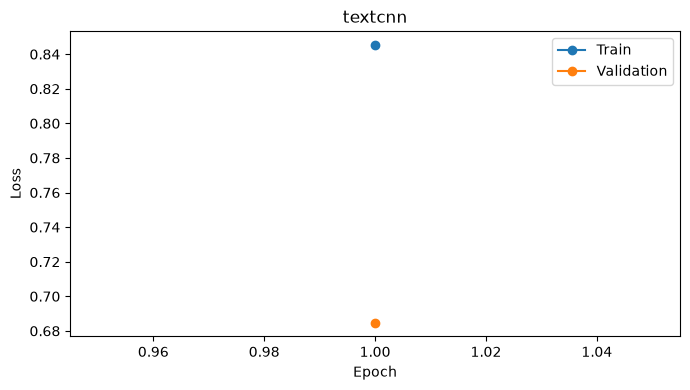

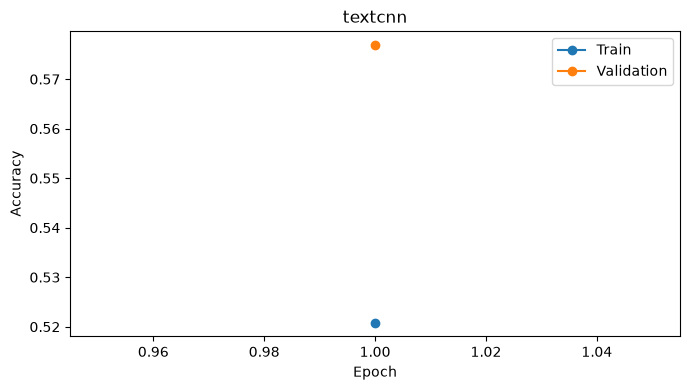

Best epoch: 1
Training examples/sec: 405.29
Memory measurements: {'process_lifetime_peak_rss_bytes': 3162132480, 'cuda_peak_allocated_bytes': 44711936}


In [38]:
seed_everything(SEED)
textcnn_config = {
    "vocab_size": VOCAB_SIZE, "embedding_dim": EMBEDDING_DIM, "pad_idx": PAD_IDX,
    **MODELS["textcnn"]
}
textcnn_model = TextCNNClassifier(**textcnn_config)
print(textcnn_model)
textcnn_run = run_training("textcnn", textcnn_model, textcnn_config)
show_training(textcnn_run)


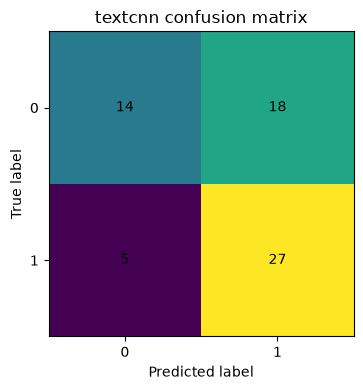

,Metric,Value
0,accuracy,0.640625
1,precision_macro,0.668421
2,recall_macro,0.640625
3,f1_macro,0.625159
4,precision_micro,0.640625
5,recall_micro,0.640625
6,f1_micro,0.640625
7,precision_weighted,0.668421
8,recall_weighted,0.640625
9,f1_weighted,0.625159


,95% lower,95% upper
accuracy_ci,0.562500,0.774219
macro_f1_ci,0.525439,0.767927
mcc_ci,0.118588,0.578971


In [39]:
textcnn_evaluation = evaluate_model(textcnn_model, textcnn_run)


### 5.3 bilstm

Packed bidirectional sequences capture context without processing padded suffixes.


BiLSTMClassifier(
  (embedding): Embedding(1767, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.4, inplace=False)
  (fc): Linear(in_features=256, out_features=1, bias=True)
)
bilstm | Epoch 01 | Train 0.6979 | Val 0.6908 | Val acc 0.5000


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,train_time_seconds,train_examples_per_second,training_examples,val_time_seconds,gradient_norm_mean,gradient_norm_max
0,1,0.697894,0.541667,0.690821,0.5,0.056598,848.091,48,0.011465,0.488378,0.565207


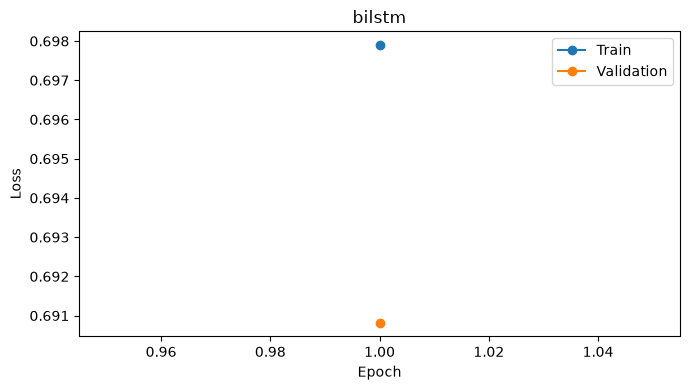

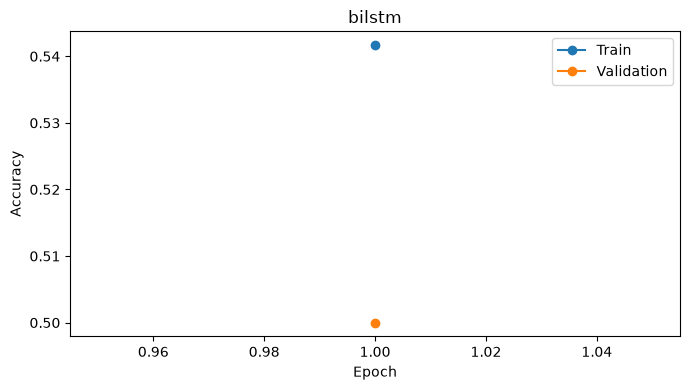

Best epoch: 1
Training examples/sec: 848.09
Memory measurements: {'process_lifetime_peak_rss_bytes': 3162132480, 'cuda_peak_allocated_bytes': 59796992}


In [40]:
seed_everything(SEED)
bilstm_config = {
    "vocab_size": VOCAB_SIZE, "embedding_dim": EMBEDDING_DIM, "pad_idx": PAD_IDX,
    **MODELS["bilstm"]
}
bilstm_model = BiLSTMClassifier(**bilstm_config)
print(bilstm_model)
bilstm_run = run_training("bilstm", bilstm_model, bilstm_config, gradient_clip=TRAINING["bilstm_gradient_clip"])
show_training(bilstm_run)


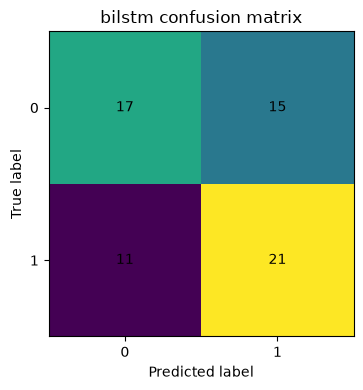

,Metric,Value
0,accuracy,0.593750
1,precision_macro,0.595238
2,recall_macro,0.593750
3,f1_macro,0.592157
4,precision_micro,0.593750
5,recall_micro,0.593750
6,f1_micro,0.593750
7,precision_weighted,0.595238
8,recall_weighted,0.593750
9,f1_weighted,0.592157


,95% lower,95% upper
accuracy_ci,0.484375,0.703125
macro_f1_ci,0.478824,0.699679
mcc_ci,-0.017200,0.416619


In [41]:
bilstm_evaluation = evaluate_model(bilstm_model, bilstm_run)


## 6. Comparison and error review

McNemar compares baseline with each experimental model on identical sample IDs.
It uses an exact two-sided binomial test on discordant pairs, with raw and
Holm-adjusted p-values. Exported metrics include resource costs, confidence
intervals, confusion counts and slice results. Formal runs update the main
metrics report; smoke runs write only their own output directory.


In [42]:
def paired_comparisons(evaluations):
    baseline = evaluations["baseline"]["predictions"]
    rows = []
    for name in ("textcnn", "bilstm"):
        current = evaluations[name]["predictions"]
        if not baseline[["sample_id", "label"]].equals(current[["sample_id", "label"]]):
            raise ValueError("McNemar requires the same test examples in the same order.")
        a = baseline["prediction"].to_numpy() == baseline["label"].to_numpy()
        b = current["prediction"].to_numpy() == current["label"].to_numpy()
        baseline_only = int((a & ~b).sum())
        experimental_only = int((~a & b).sum())
        discordant = baseline_only + experimental_only
        rows.append({
            "comparison": "baseline_vs_" + name, "experimental_model": name,
            "both_correct": int((a & b).sum()), "both_wrong": int((~a & ~b).sum()),
            "baseline_only_correct": baseline_only, "experimental_only_correct": experimental_only,
            "p_value": float(binomtest(baseline_only, discordant, 0.5).pvalue) if discordant else 1.0,
        })
    order = sorted(range(len(rows)), key=lambda i: rows[i]["p_value"])
    previous = 0.0
    for rank, index in enumerate(order):
        previous = max(previous, min(1.0, (len(rows) - rank) * rows[index]["p_value"]))
        rows[index]["p_value_holm"] = previous
    return pd.DataFrame(rows)


def export_comparison(session, evaluations):
    if set(evaluations) != {"baseline", "textcnn", "bilstm"}:
        raise ValueError("Evaluate all three models before exporting the comparison.")
    paired = paired_comparisons(evaluations)
    paired_path = session["outputs"] / "mcnemar.csv"
    paired.to_csv(paired_path, index=False)
    rows = []
    root = session["root"]

    def add(run, metric, value, unit, evidence, group="test", split="test"):
        rows.append({
            "model_id": run["run_id"], "direction_or_slice": group, "metric": metric,
            "value": "not_measured" if value is None or pd.isna(value) else value,
            "unit": unit, "split": split, "checkpoint_id": run["best_checkpoint"],
            "evidence_path": evidence.relative_to(root).as_posix(),
        })

    for name, evaluation in evaluations.items():
        run = evaluation["run"]
        output = run["output_path"]
        for key, value in evaluation["metrics"].items():
            add(run, key, value, "fraction" if key != "mcc" else "correlation", output / "evaluation.json")
        for key, bounds in evaluation["confidence_intervals"].items():
            for suffix, value in zip(("lower", "upper"), bounds):
                add(run, key + "_" + suffix, value,
                    "correlation" if key.startswith("mcc") else "fraction", output / "evaluation.json")
        for key, value in zip(("tn", "fp", "fn", "tp"), np.asarray(evaluation["confusion_matrix"]).ravel()):
            add(run, "confusion_" + key, int(value), "examples", output / "evaluation.json")
        for key, unit in (("parameter_count", "parameters"), ("training_loop_seconds", "seconds"),
                          ("training_wall_seconds_this_segment", "seconds"),
                          ("training_wall_seconds_including_resume", "seconds"),
                          ("training_examples_per_second", "examples/second"), ("nonfinite_events", "events")):
            add(run, key, run[key], unit, output / "training_summary.json", "training", "training")
        for key, value in run["memory"].items():
            add(run, key, value, "bytes", output / "training_summary.json", "training", "training")
        for _, row in evaluation["slices"].iterrows():
            for key in ("count", "macro_f1", "error_rate"):
                add(run, key, row[key], "examples" if key == "count" else "fraction",
                    output / "slice_metrics.csv", row["slice"])
        summary = {**evaluation["metrics"], "model": name, "run_id": run["run_id"],
                   "parameter_count": run["parameter_count"],
                   "training_seconds": run["training_loop_seconds"]}
        pd.DataFrame([summary]).to_csv(output / "metrics.csv", index=False)
    for _, row in paired.iterrows():
        run = evaluations[row["experimental_model"]]["run"]
        for key in ("p_value", "p_value_holm", "baseline_only_correct", "experimental_only_correct",
                    "both_correct", "both_wrong"):
            add(run, "mcnemar_" + key, row[key], "probability" if key.startswith("p_") else "examples",
                paired_path, row["comparison"])
    frame = pd.DataFrame(rows)
    frame.to_csv(session["outputs"] / "metrics_report.csv", index=False)
    if session["mode"] == "formal":
        frame.to_csv(session["member"] / "metrics_report.csv", index=False)
        save_json(session["member"] / "outputs/latest.json",
                  {"session_id": session["id"], "runs": {name: value["run_id"] for name, value in evaluations.items()},
                   "metrics": (session["outputs"] / "metrics_report.csv").relative_to(root).as_posix()})
    print("Saved", session["mode"], "comparison:", (session["outputs"] / "metrics_report.csv").relative_to(root))
    return frame, paired


In [43]:
evaluations = {
    "baseline": baseline_evaluation,
    "textcnn": textcnn_evaluation,
    "bilstm": bilstm_evaluation
}
metrics_report, mcnemar_results = export_comparison(session, evaluations)
display(pd.DataFrame({name: value["metrics"] for name, value in evaluations.items()}).T)
display(mcnemar_results)
for name, result in evaluations.items():
    print(name, "|", MODE)
    display(result["slices"])


Saved smoke comparison: task2_sentiment\Yuyao_Ding\outputs\task2_smoke_20260927T015718Z_bd069b3e\metrics_report.csv


,accuracy,precision_macro,recall_macro,f1_macro,precision_micro,recall_micro,f1_micro,precision_weighted,recall_weighted,f1_weighted,roc_auc,pr_auc,average_precision,mcc,brier_score,ece
baseline,0.500000,0.250000,0.500000,0.333333,0.500000,0.500000,0.500000,0.250000,0.500000,0.333333,0.503906,0.479212,0.500249,0.000000,0.252926,0.062888
textcnn,0.640625,0.668421,0.640625,0.625159,0.640625,0.640625,0.640625,0.668421,0.640625,0.625159,0.650391,0.600888,0.613902,0.307794,0.243243,0.130704
bilstm,0.593750,0.595238,0.593750,0.592157,0.593750,0.593750,0.593750,0.595238,0.593750,0.592157,0.632812,0.670376,0.676466,0.188982,0.245773,0.076875


,comparison,experimental_model,both_correct,both_wrong,baseline_only_correct,experimental_only_correct,p_value,p_value_holm
0,baseline_vs_textcnn,textcnn,14,5,18,27,0.232693,0.465386
1,baseline_vs_bilstm,bilstm,17,11,15,21,0.405032,0.465386


baseline | smoke


,slice,count,negative_examples,positive_examples,macro_f1,error_rate
0,length_short,13,7,6,0.350000,0.461538
1,length_medium,31,13,18,0.295455,0.580645
2,length_long,20,12,8,0.375000,0.400000
3,has_negation,50,25,25,0.333333,0.500000
4,no_negation,14,7,7,0.333333,0.500000
5,truncated,4,3,1,0.428571,0.250000
6,not_truncated,60,29,31,0.325843,0.516667
7,empty_after_preprocessing,0,0,0,NaN,NaN


textcnn | smoke


,slice,count,negative_examples,positive_examples,macro_f1,error_rate
0,length_short,13,7,6,0.606061,0.384615
1,length_medium,31,13,18,0.658507,0.290323
2,length_long,20,12,8,0.548872,0.450000
3,has_negation,50,25,25,0.648615,0.340000
4,no_negation,14,7,7,0.533333,0.428571
5,truncated,4,3,1,0.733333,0.250000
6,not_truncated,60,29,31,0.612221,0.366667
7,empty_after_preprocessing,0,0,0,NaN,NaN


bilstm | smoke


,slice,count,negative_examples,positive_examples,macro_f1,error_rate
0,length_short,13,7,6,0.690476,0.307692
1,length_medium,31,13,18,0.592105,0.387097
2,length_long,20,12,8,0.494949,0.500000
3,has_negation,50,25,25,0.578483,0.420000
4,no_negation,14,7,7,0.641026,0.357143
5,truncated,4,3,1,0.733333,0.250000
6,not_truncated,60,29,31,0.580420,0.416667
7,empty_after_preprocessing,0,0,0,NaN,NaN


In [44]:
for name, result in evaluations.items():
    path = result["run"]["output_path"] / "error_review.csv"
    print(name, "| Error review:", path)
    review = pd.read_csv(path, keep_default_na=False)
    display(review[["sample_id", "category", "true_label", "predicted_label",
                    "positive_probability", "text"]])
print("After formal training, use these saved results to finish results.md and failure_analysis.md.")


baseline | Error review: C:\Users\endle\Downloads\DATA266_Pair41_Lab1\DATA266_Pair41_Lab1-main\task2_sentiment\Yuyao_Ding\outputs\task2_smoke_20260927T015718Z_bd069b3e\baseline\error_review.csv


,sample_id,category,true_label,predicted_label,positive_probability,text
0,test_30943,confident_false_negative,1,0,0.416346,Started going here last year when my previous ...
1,test_37165,confident_false_negative,1,0,0.417959,Sparky is AWESOME!!!! SANG along with me to t...
2,test_20692,confident_false_negative,1,0,0.425271,After about a year of running in really inappr...
3,test_18742,confident_false_negative,1,0,0.432311,On a good day with experienced help and the be...
4,test_33168,confident_false_negative,1,0,0.434130,Such an awesome delivery service! Why hasn't a...
5,test_10249,near_threshold,1,0,0.490891,"The waiter we had was terrible, for a high cla..."
6,test_31385,near_threshold,1,0,0.489213,My wife and I went to Brazz on a Groupon disco...
7,test_16586,near_threshold,1,0,0.482624,Had the prix fixe menu featuring Hot & Sour So...
8,test_32574,near_threshold,1,0,0.482589,Now don't expect a great dining experience. Ex...
9,test_1173,near_threshold,1,0,0.477780,Stellar! One of my favorite places to eat in a...


textcnn | Error review: C:\Users\endle\Downloads\DATA266_Pair41_Lab1\DATA266_Pair41_Lab1-main\task2_sentiment\Yuyao_Ding\outputs\task2_smoke_20260927T015718Z_bd069b3e\textcnn\error_review.csv


,sample_id,category,true_label,predicted_label,positive_probability,text
0,test_1888,confident_false_positive,0,1,0.612379,Stay as far away from this salon as possible! ...
1,test_3364,confident_false_positive,0,1,0.607300,HORRIBLE SERVICE!\n\nThis store offered to shi...
2,test_16844,confident_false_positive,0,1,0.595875,Confirmed: The place is permanently closed eff...
3,test_16481,confident_false_positive,0,1,0.583546,"Horrible...just horrible. Bad service, under ..."
4,test_14113,confident_false_positive,0,1,0.560946,I dont think the price is worth the food. I as...
5,test_20692,confident_false_negative,1,0,0.464120,After about a year of running in really inappr...
6,test_37705,confident_false_negative,1,0,0.481809,"Between myself and my husband, we've been to d..."
7,test_4199,confident_false_negative,1,0,0.494239,It was ok. Was there for Saturday night rib n...
8,test_18722,confident_false_negative,1,0,0.496881,I've been going to Tum Nak Thai for over 4 yea...
9,test_6646,confident_false_negative,1,0,0.497383,"OK, finally lost my Tempe Improv V-Card. Why i..."


bilstm | Error review: C:\Users\endle\Downloads\DATA266_Pair41_Lab1\DATA266_Pair41_Lab1-main\task2_sentiment\Yuyao_Ding\outputs\task2_smoke_20260927T015718Z_bd069b3e\bilstm\error_review.csv


,sample_id,category,true_label,predicted_label,positive_probability,text
0,test_26770,confident_false_positive,0,1,0.527544,"I never actually ate at this mobile dump, but ..."
1,test_16844,confident_false_positive,0,1,0.526656,Confirmed: The place is permanently closed eff...
2,test_9909,confident_false_positive,0,1,0.526186,I would give this place NEGATIVE STARS if I co...
3,test_29833,confident_false_positive,0,1,0.522898,I went to the Mint with my family when they we...
4,test_10813,confident_false_positive,0,1,0.518842,"As a dedicated Yelper, I usually check places ..."
5,test_10249,confident_false_negative,1,0,0.466297,"The waiter we had was terrible, for a high cla..."
6,test_36800,confident_false_negative,1,0,0.467493,Waited to review until all the freshness had w...
7,test_18082,confident_false_negative,1,0,0.469143,"If you want excellent coffee, an interesting b..."
8,test_32574,confident_false_negative,1,0,0.471485,Now don't expect a great dining experience. Ex...
9,test_33168,confident_false_negative,1,0,0.472900,Such an awesome delivery service! Why hasn't a...


After formal training, use these saved results to finish results.md and failure_analysis.md.


## 7. Predict a review

The models above have already reloaded their validation-selected checkpoints.
Change the review below to compare their predictions. This cell needs no
additional training and uses the same preprocessing and decision threshold.


In [45]:
review = "The food was good, but the service was not."
review_ids = torch.tensor([encode_text(preprocess_text(review))], dtype=torch.long)
with torch.no_grad():
    for name, model in (("baseline", baseline_model), ("textcnn", textcnn_model), ("bilstm", bilstm_model)):
        model.eval()
        probability = torch.sigmoid(model(review_ids)).item()
        print(name, "|", "positive" if probability >= THRESHOLD else "negative",
              "| P(positive):", round(probability, 4), "|", MODE)


baseline | negative | P(positive): 0.4459 | smoke
textcnn | positive | P(positive): 0.523 | smoke
bilstm | positive | P(positive): 0.5083 | smoke
